In [3]:
import pandas as pd
import pypsa

In [26]:
network = pypsa.Network()
hours_in_2015 = pd.date_range('2015-01-01 00:00Z',
                              '2015-12-31 23:00Z',
                              freq='h')

network.set_snapshots(hours_in_2015.values)

network.add("Bus",
            "electricity bus")

network.snapshots

DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 01:00:00',
               '2015-01-01 02:00:00', '2015-01-01 03:00:00',
               '2015-01-01 04:00:00', '2015-01-01 05:00:00',
               '2015-01-01 06:00:00', '2015-01-01 07:00:00',
               '2015-01-01 08:00:00', '2015-01-01 09:00:00',
               ...
               '2015-12-31 14:00:00', '2015-12-31 15:00:00',
               '2015-12-31 16:00:00', '2015-12-31 17:00:00',
               '2015-12-31 18:00:00', '2015-12-31 19:00:00',
               '2015-12-31 20:00:00', '2015-12-31 21:00:00',
               '2015-12-31 22:00:00', '2015-12-31 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=8760, freq=None)

In [5]:
# load electricity demand data
df_elec = pd.read_csv('data/electricity_demand.csv', sep=';', index_col=0) # in MWh
df_elec.index = pd.to_datetime(df_elec.index) #change index to datatime
country='SWE'
print(df_elec[country].head())

utc_time
2015-01-01 00:00:00+00:00    14845.0
2015-01-01 01:00:00+00:00    14554.0
2015-01-01 02:00:00+00:00    14267.0
2015-01-01 03:00:00+00:00    14224.0
2015-01-01 04:00:00+00:00    14370.0
Name: SWE, dtype: float64


In [6]:
#network.set_snapshots(df_elec.index)
#network.snapshots

In [7]:
# add load to the bus
network.add("Load",
            "load",
            bus="electricity bus",
            p_set=df_elec[country].values)

In [8]:
network.loads_t.p_set

name,load
snapshot,
2015-01-01 00:00:00,14845.0
2015-01-01 01:00:00,14554.0
2015-01-01 02:00:00,14267.0
2015-01-01 03:00:00,14224.0
2015-01-01 04:00:00,14370.0
...,...
2015-12-31 19:00:00,17548.0
2015-12-31 20:00:00,16973.0
2015-12-31 21:00:00,16469.0


In [9]:
def annuity(n,r):
    """ Calculate the annuity factor for an asset with lifetime n years and
    discount rate  r """

    if r > 0:
        return r/(1. - 1./(1.+r)**n)
    else:
        return 1/n

In [11]:
# We add the different carries: nuclear, gas, solar and wind

network.add("Carrier", "onshorewind")
network.add("Carrier", "offshorewind")
network.add("Carrier", "solar")
network.add("Carrier", "nuclear")
network.add("Carrier", "gas", co2_emissions=0.19) # in t_CO2/MWh_th
country = 'SWE'

# add onshore wind generator
df_onshorewind = pd.read_csv('data/CF_onshore_wind_1979-2017.csv', sep=';', index_col=0)
df_onshorewind.index = pd.to_datetime(df_onshorewind.index)
CF_wind = df_onshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
capital_cost_onshorewind = annuity(30,0.07)*910000*(1+0.033) # in €/MW
network.add("Generator",
            "onshorewind",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="onshorewind",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_onshorewind,
            marginal_cost = 0,
            p_max_pu = CF_wind.values)


# add offshore wind generator
df_offshorewind = pd.read_csv('data/CF_offshore_wind_1979-2017.csv', sep=';', index_col=0)
df_offshorewind.index = pd.to_datetime(df_offshorewind.index)
CF_wind = df_offshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
capital_cost_offshorewind = annuity(30,0.07)*910000*(1+0.033) # in €/MW
network.add("Generator",
            "offshorewind",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="offshorewind",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_offshorewind,
            marginal_cost = 0,
            p_max_pu = CF_wind.values)


# add solar PV generator
df_solar = pd.read_csv('data/CF_pv_optimal.csv', sep=';', index_col=0)
df_solar.index = pd.to_datetime(df_solar.index)
CF_solar = df_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
capital_cost_solar = annuity(25,0.07)*425000*(1+0.03) # in €/MW
network.add("Generator",
            "solar",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="solar",
            #p_nom_max=1000, # maximum capacity can be limited due to environmental constraints
            capital_cost = capital_cost_solar,
            marginal_cost = 0,
            p_max_pu = CF_solar.values)


# add nuclear generator
life_nuclear = 60                    # years
cap_nuclear = 6000000               # €/MW_el
fom_nuclear = 0.025                 # 2.5%/year
capital_cost_nuclear = annuity(life_nuclear, 0.07) * cap_nuclear * (1 + fom_nuclear)

marginal_cost_nuclear = 10.0        # €/MWh_el (example stylized value)

network.add("Generator",
            "nuclear",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="nuclear",
            capital_cost=capital_cost_nuclear,
            marginal_cost=marginal_cost_nuclear)


# add OCGT (Open Cycle Gas Turbine) generator
capital_cost_OCGT = annuity(25,0.07)*560000*(1+0.033) # in €/MW
fuel_cost = 21.6 # in €/MWh_th
efficiency = 0.39 # MWh_elec/MWh_th
marginal_cost_OCGT = fuel_cost/efficiency # in €/MWh_el
network.add("Generator",
            "OCGT",
            bus="electricity bus",
            p_nom_extendable=True,
            carrier="gas",
            #p_nom_max=1000,
            capital_cost = capital_cost_OCGT,
            marginal_cost = marginal_cost_OCGT)


In [12]:
network.generators_t.p_max_pu

name,onshorewind,offshorewind,solar
snapshot,,,
2015-01-01 00:00:00,0.376,0.668,0.0
2015-01-01 01:00:00,0.376,0.698,0.0
2015-01-01 02:00:00,0.377,0.718,0.0
2015-01-01 03:00:00,0.386,0.714,0.0
2015-01-01 04:00:00,0.396,0.713,0.0
...,...,...,...
2015-12-31 19:00:00,0.282,0.401,0.0
2015-12-31 20:00:00,0.261,0.341,0.0
2015-12-31 21:00:00,0.244,0.333,0.0


In [13]:
network.optimize(solver_name='gurobi')

/var/folders/k2/mns8khpd5j76cc436d914hvw0000gn/T/ipykernel_33544/3854944838.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name='gurobi')
Index(['electricity bus'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 325.58it/s]
INFO:linopy.io: Writing time: 0.27s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2790071


INFO:gurobipy:Set parameter LicenseID to value 2790071


...

Solved in 14183 iterations and 1.44 seconds (0.88 work units)


INFO:gurobipy:Solved in 14183 iterations and 1.44 seconds (0.88 work units)


Optimal objective  5.888558955e+09


INFO:gurobipy:Optimal objective  5.888558955e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43805 primals, 96365 duals
Objective: 5.89e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


('ok', 'optimal')

In [14]:
print(network.objective/1000000) #in 10^6 €

5888.558954670033


In [15]:
print(network.objective/network.loads_t.p.sum()) # EUR/MWh

name
load    43.321675
dtype: float64


In [16]:
network.generators.p_nom_opt # in MW

name
onshorewind         0.000000
offshorewind    32294.466403
solar               0.000000
nuclear             0.000000
OCGT            22178.638340
Name: p_nom_opt, dtype: float64

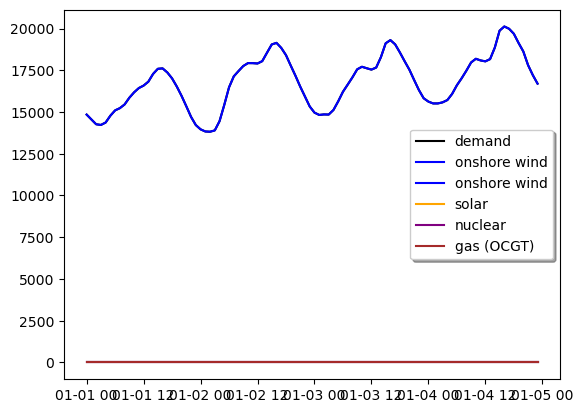

In [17]:
import matplotlib.pyplot as plt

plt.plot(network.loads_t.p['load'][0:96], color='black', label='demand')
plt.plot(network.generators_t.p['onshorewind'][0:96], color='blue', label='onshore wind')
plt.plot(network.generators_t.p['offshorewind'][0:96], color='blue', label='onshore wind')
plt.plot(network.generators_t.p['solar'][0:96], color='orange', label='solar')
plt.plot(network.generators_t.p['nuclear'][0:96], color='purple', label='nuclear')
plt.plot(network.generators_t.p['OCGT'][0:96], color='brown', label='gas (OCGT)')
plt.legend(fancybox=True, shadow=True, loc='best')

Text(0.5, 1.07, 'Electricity mix')

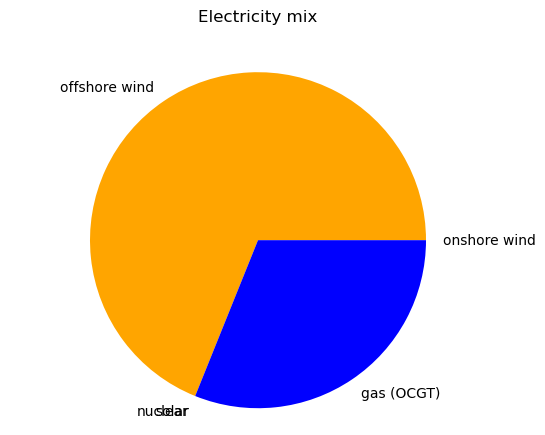

In [18]:
labels = ['onshore wind',
          'offshore wind',
          'solar',
          'nuclear',    
          'gas (OCGT)']
sizes = [network.generators_t.p['onshorewind'].sum(),
         network.generators_t.p['offshorewind'].sum(),
         network.generators_t.p['solar'].sum(),
         network.generators_t.p['nuclear'].sum(),
         network.generators_t.p['OCGT'].sum()]

colors=['blue', 'orange', 'brown', 'green'] 

plt.pie(sizes,
        colors=colors,
        labels=labels,
        wedgeprops={'linewidth':0})
plt.axis('equal')

plt.title('Electricity mix', y=1.07)

In [19]:
co2_limit=1000000 #tonCO2
network.add("GlobalConstraint",
            "co2_limit",
            type="primary_energy",
            carrier_attribute="co2_emissions",
            sense="<=",
            constant=co2_limit)
network.optimize(solver_name='gurobi')

/var/folders/k2/mns8khpd5j76cc436d914hvw0000gn/T/ipykernel_33544/2428468447.py:8: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize(solver_name='gurobi')
Index(['electricity bus'], dtype='object', name='name')
Index(['0'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 2/2 [00:00<00:00, 431.02it/s]
INFO:linopy.io: Writing time: 0.09s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2790071


INFO:gurobipy:Set parameter LicenseID to value 2790071


...

Solved in 7880 iterations and 2.25 seconds (1.60 work units)


INFO:gurobipy:Solved in 7880 iterations and 2.25 seconds (1.60 work units)


Optimal objective  8.027046467e+09


INFO:gurobipy:Optimal objective  8.027046467e+09
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43805 primals, 96366 duals
Objective: 8.03e+09
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper were not assigned to the network.


ValueError: setting an array element with a sequence.

In [20]:
network.generators.p_nom_opt #in MW

name
onshorewind         0.000000
offshorewind    25088.717474
solar            5869.212138
nuclear         10425.871011
OCGT            11932.911053
Name: p_nom_opt, dtype: float64

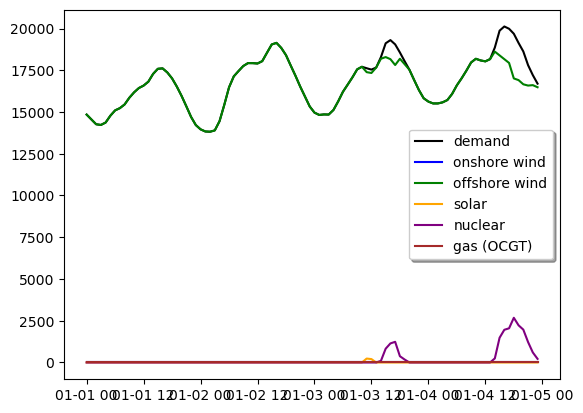

In [21]:
plt.plot(network.loads_t.p['load'][0:96], color='black', label='demand')
plt.plot(network.generators_t.p['onshorewind'][0:96], color='blue', label='onshore wind')
plt.plot(network.generators_t.p['offshorewind'][0:96], color='green', label='offshore wind')
plt.plot(network.generators_t.p['solar'][0:96], color='orange', label='solar')
plt.plot(network.generators_t.p['nuclear'][0:96], color='purple', label='nuclear')
plt.plot(network.generators_t.p['OCGT'][0:96], color='brown', label='gas (OCGT)')
plt.legend(fancybox=True, shadow=True, loc='best')

Text(0.5, 1.07, 'Electricity mix')

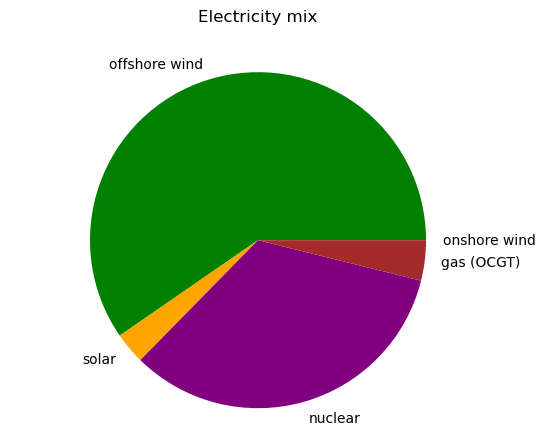

In [22]:
labels = ['onshore wind', 'offshore wind', 'solar', 'nuclear', 'gas (OCGT)' ]
sizes = [network.generators_t.p['onshorewind'].sum(),
         network.generators_t.p['offshorewind'].sum(),
         network.generators_t.p['solar'].sum(),
         network.generators_t.p['nuclear'].sum(),
         network.generators_t.p['OCGT'].sum()]

colors = ['blue', 'green', 'orange', 'purple', 'brown']

plt.pie(sizes,
        colors=colors,
        labels=labels,
        wedgeprops={'linewidth':0})
plt.axis('equal')

plt.title('Electricity mix', y=1.07)

## Part A

hoose a different country/region/city/system and calculate the optimal capacities for renewable and non-renewable generators. You can add as many technologies as you want. Remember to provide a reference for the cost assumptions. Plot the dispatch time series for a week in summer and winter. Plot the annual electricity mix. Use the duration curves or the capacity factor to investigate the contribution of different technologies.

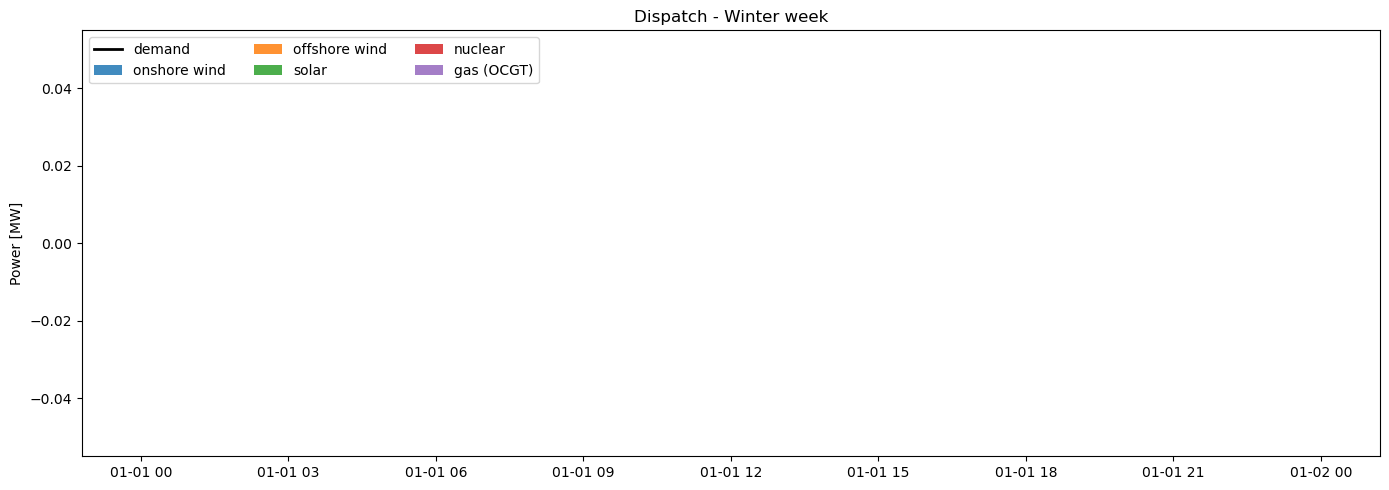

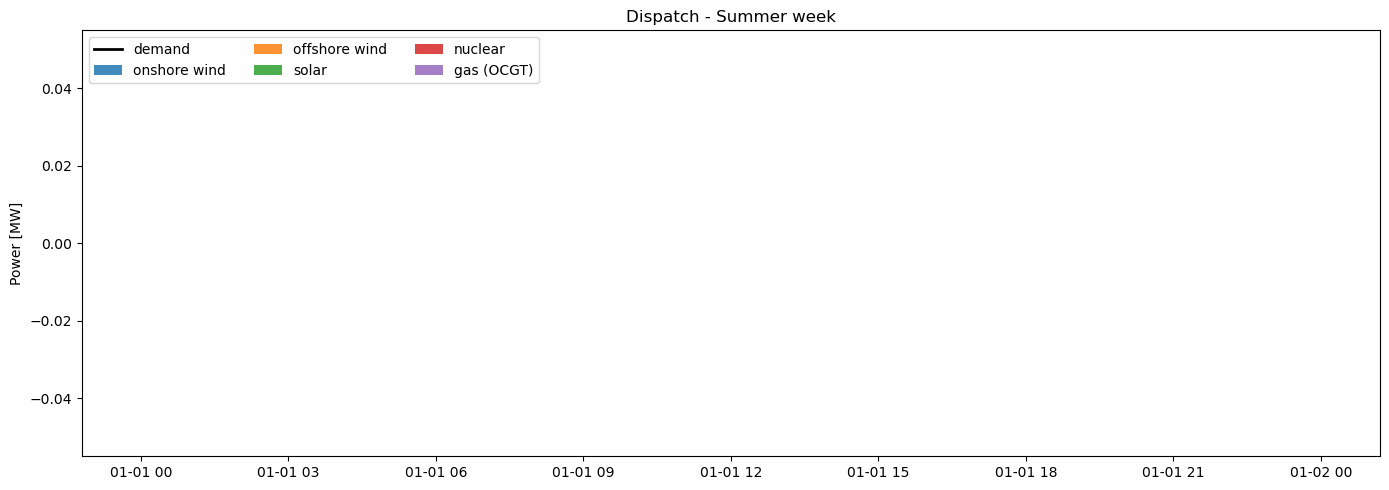

In [23]:
# Winter week and summer week 
import matplotlib.pyplot as plt

def plot_dispatch_week(network, start_date, end_date, title):
    dispatch = network.generators_t.p.loc[start_date:end_date, ["onshorewind", "offshorewind", "solar", "nuclear", "OCGT"]]
    demand = network.loads_t.p.loc[start_date:end_date, "load"]

    plt.figure(figsize=(14, 5))
    plt.plot(demand.index, demand, color="black", linewidth=2, label="demand")
    plt.stackplot(dispatch.index,
                  dispatch["onshorewind"],
                  dispatch["offshorewind"],
                  dispatch["solar"],
                  dispatch["nuclear"],
                  dispatch["OCGT"],
                  labels=["onshore wind", "offshore wind", "solar", "nuclear", "gas (OCGT)"],
                  alpha=0.85)
    plt.title(title)
    plt.ylabel("Power [MW]")
    plt.legend(loc="upper left", ncol=3)
    plt.tight_layout()
    plt.show()

plot_dispatch_week(network,
                   "2017-01-02 00:00:00",
                   "2017-01-08 23:00:00",
                   "Dispatch - Winter week")

plot_dispatch_week(network,
                   "2017-07-03 00:00:00",
                   "2017-07-09 23:00:00",
                   "Dispatch - Summer week")

Annual generation by technology (MWh):
name
offshorewind    81029818.0
nuclear         45501838.0
OCGT             5263158.0
solar            4131576.0
onshorewind            0.0
dtype: float64


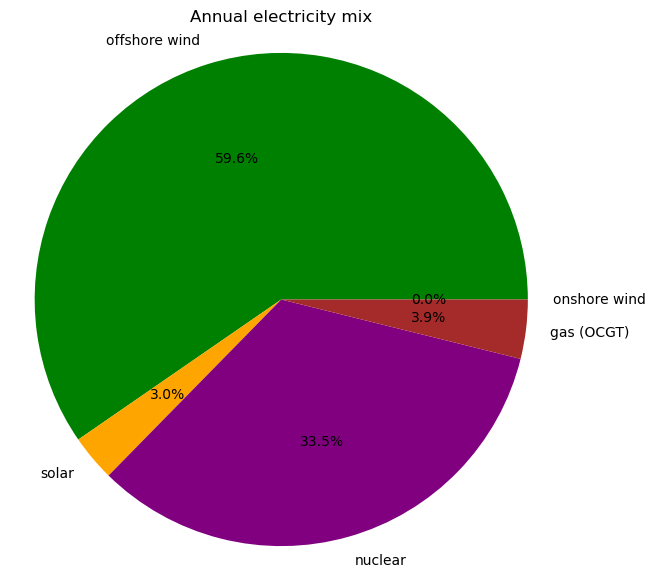

In [24]:
# Annual generation
annual_generation = network.generators_t.p.sum().sort_values(ascending=False)
print("Annual generation by technology (MWh):")
print(annual_generation.round(0))

labels = ["onshore wind", "offshore wind", "solar", "nuclear", "gas (OCGT)"]
sizes = [
    network.generators_t.p["onshorewind"].sum(),
    network.generators_t.p["offshorewind"].sum(),
    network.generators_t.p["solar"].sum(),
    network.generators_t.p["nuclear"].sum(),
    network.generators_t.p["OCGT"].sum()
]

colors = ["blue", "green", "orange", "purple", "brown"]

plt.figure(figsize=(7, 7))
plt.pie(sizes,
        labels=labels,
        colors=colors,
        autopct="%1.1f%%",
        wedgeprops={"linewidth": 0})
plt.axis("equal")
plt.title("Annual electricity mix")
plt.show()

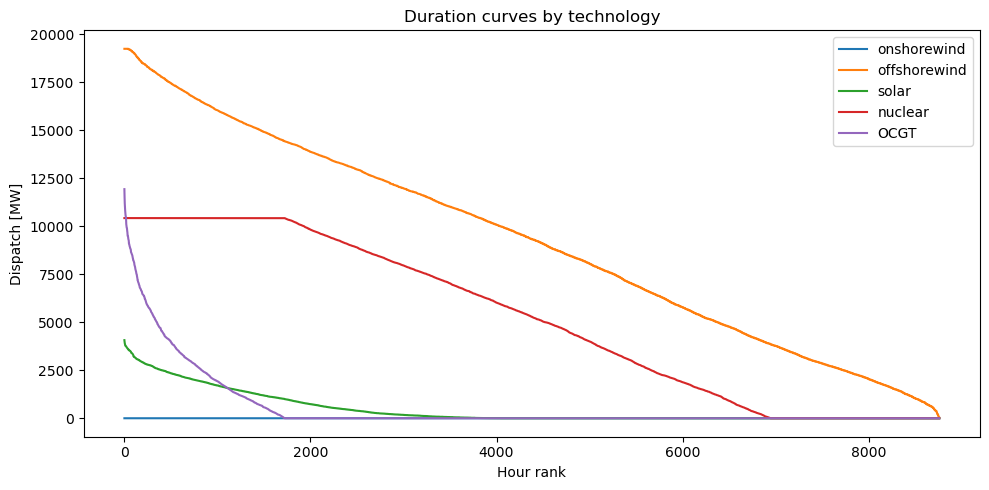

In [25]:
# Duration curves

# %%
plt.figure(figsize=(10, 5))

for tech in ["onshorewind", "offshorewind", "solar", "nuclear", "OCGT"]:
    sorted_dispatch = network.generators_t.p[tech].sort_values(ascending=False).reset_index(drop=True)
    plt.plot(sorted_dispatch, label=tech)

plt.xlabel("Hour rank")
plt.ylabel("Dispatch [MW]")
plt.title("Duration curves by technology")
plt.legend()
plt.tight_layout()
plt.show()

## Part B

Investigate how sensitive your results are to the interannual variability of solar and wind generation. Plot the average capacity and variability obtained for every generator using different weather years.

In [ ]:
weather_years = range(2000, 2018)   # only adding 18 years cause if not it's too slow :(
results = []

# keep 2017 demand for all runs to isolate weather sensitivity
load_2017 = df_elec["Actual Total Load (MW)"].values

for year in weather_years:
    print(f"Running weather year {year}...")

    # 1. Create snapshots for this weather year
    new_snapshots = pd.date_range(f"{year}-01-01 00:00", f"{year}-12-31 23:00", freq="h")
    network.set_snapshots(new_snapshots)

    # 2. Extract renewable profiles for this exact year
    onshore_year = df_onshorewind[country][df_onshorewind.index.year == year]
    offshore_year = df_offshorewind[country][df_offshorewind.index.year == year]
    solar_year = df_solar[country][df_solar.index.year == year]

    # 3. Make sure lengths match
    if not (len(onshore_year) == len(new_snapshots) == len(offshore_year) == len(solar_year)):
        print(f"Skipping {year}: mismatch in time series length")
        continue

    # 4. Update renewable availability
    network.generators_t.p_max_pu.loc[:, "onshorewind"] = onshore_year.values
    network.generators_t.p_max_pu.loc[:, "offshorewind"] = offshore_year.values
    network.generators_t.p_max_pu.loc[:, "solar"] = solar_year.values

    # 5. Update load
    if len(load_2017) == len(new_snapshots):
        network.loads_t.p_set.loc[:, "load"] = load_2017
    else:
        print(f"Skipping {year}: load length mismatch")
        continue

    # 6. Optimize
    network.optimize(solver_name="gurobi")

    # 7. Store capacities
    opt_caps = network.generators.p_nom_opt.copy()
    opt_caps["year"] = year
    results.append(opt_caps)

# 8. Collect all results
df_sensitivity = pd.DataFrame(results).set_index("year")

print(df_sensitivity)